___


# <font color= #8A0829> Proyecto Taller de Modelado de Datos Segunda Entrega Regresion </font>
- <Strong> NOMBRE ALUMNOS: </Strong> `DIEGO EDUARDO MARTINEZ SINCEL \  OWEN DAVID LOZA` 
- <Strong> Año </Strong>: 2025
- <Strong> Email: </Strong>  <font color="blue"> `diegoe.martinez@iteso.mx \ owen.loza@iteso.mx` </font>
___


### Entrega2

2.1. **Procesar modelo de regresión:** 
- Una vez sugerido un modelo que se puede aplicar a tu dataset, se pide que compares al menos 4 modelos de regresión para estimar predicciones en tus datos y los compares utilizando métricas de performance. 
- La intención principal es hacer una comparación del performance de cada modelo, incluyendo la mención de la complejidad (número de parámetros y tiempo de ejecución).
- Se pide añadir un método de ajuste de hiperparámetros para mejorar el performance del modelo. 
- Se pide justificar cuál métrica de performance es la mejor para utilizar en tu dataset (MSE, MAE, R2) (puedes utilizar varias si es que así lo crees necesario). 
- Una vez comparados los 4 modelos y elegido el mejor modelo dadas las métricas de performance, compara si tu respuesta inicial sobre cuál modelo era el mejor para tus datos es igual al resultado de comparar los 4 modelos.
- Observa si tu modelo está haciendo overfitting o underfitting
- Crear un conjunto de datos "nuevos" donde se prediga la variable objetivo para esos nuevos datos utilizando el mejor modelo que obtuviste. 

2.2. **Discusión de los resultados:** 
- Basado en los resultados de la comparación y performance de los modelos, generar una sección de conclusiones donde se hable de las ventajas y desventajas de los modelos propuestos. 
- Explica qué variables fueron las más importantes en tu modelo y qué relaciones interesantes viste sobre tus datos. 

In [336]:
# Primero tengo que dropear las variables que podrían tener o darnos leakage por distintas razones,
#  en este caso son promedios derivados de nuestra variabel objetivo
df_reg = df_ordenado.drop(columns=["Player", "Key", "Points_half-ppr", "PPT_half-ppr", "PointsOvrRank_half-ppr", "PointsPosRank_half-ppr", 
                                   "PPGOvrRank_half-ppr", "PPGPosRank_half-ppr", "PPTOvrRank_half-ppr", "PPTPosRank_half-ppr", 
                                   "Points_VORP_half-ppr", "PPG_VORP_half-ppr", "ProBowl", "AllPro"])

In [337]:
# Quitamos los promedios para evitar colinealidad
df_reg = df_reg.drop(columns=["Pass_Cmp_per_game", "Pass_Att_per_game", "Pass_Yds_per_game", "Pass_TD_per_game", "Pass_Int_per_game",
                     "Rush_Att_per_game", "Rush_Yds_per_game", "Rush_TD_per_game", "Rec_Tgt_per_game", "Rec_Rec_per_game", "Rec_Yds_per_game",
                     "Rec_TD_per_game", "Fmb_per_game", "FmbLost_per_game", "Scrim_TD_per_game", "Scrim_Yds_per_game", "Touches_per_game"])

In [338]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
# Ahora vamos a hacer el one hot, para tratar las variables 

X = df_reg.drop(columns=[target], errors="ignore")
y = df_reg[target].astype(float)

cat_cols = [c for c in ["Pos", "Tm"] if c in X.columns]
num_cols = X.select_dtypes(include=np.number).columns.tolist()

# Pipelines por tipo
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

# nuestra división de train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# fit con solo el train para que no afecte
pre.fit(X_train)
X_train_proc = pre.transform(X_train)
X_test_proc  = pre.transform(X_test)

print("Shapes =", X_train_proc.shape, X_test_proc.shape)



Shapes = (11914, 72) (2979, 72)


Se pide que propongamos un modelo antes de empezar y decidimos elegir y pensamos que el mejor sería un SVR por la cantidad de datos, porque quitamos lo máximo que pudimos sober colinealidades y realmente no necesita relaciones con nuevas variables feature. 

In [339]:
# El primer modelo que vamos a usar es Lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

alpha = 0.1  
lasso = Pipeline(steps=[
    ("pre", pre),                
    ("model", Lasso(alpha=alpha, max_iter=20000))
])

# Entrenar
lasso.fit(X_train, y_train)

# Predicciones
yhat_tr = lasso.predict(X_train)
yhat_te = lasso.predict(X_test)

# r2
mae_tr = mean_absolute_error(y_train, yhat_tr)
r2_tr  = r2_score(y_train,  yhat_tr)
mae_te = mean_absolute_error(y_test,  yhat_te)
r2_te  = r2_score(y_test,   yhat_te)

print(f"Lasso")
print(f"Train  MAE: {mae_tr:.3f} | R²: {r2_tr:.3f}")
print(f"Test   MAE: {mae_te:.3f} | R²: {r2_te:.3f}")

Lasso
Train  MAE: 0.876 | R²: 0.922
Test   MAE: 0.894 | R²: 0.921


<Axes: xlabel='PPG_half-ppr'>

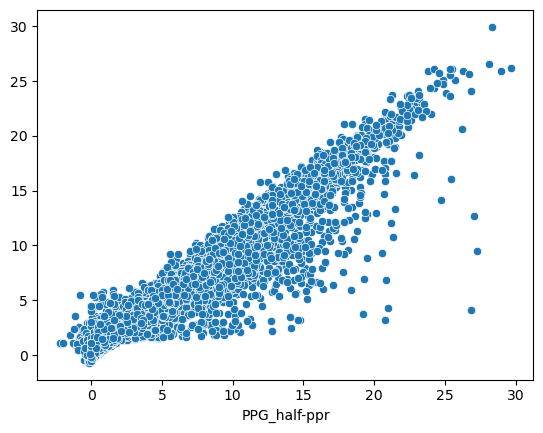

In [340]:
sns.scatterplot(x=y_train, y=lasso.predict(X_train))

In [341]:
# Ahora haciendo Linear Regression
from sklearn.linear_model import LinearRegression

linearreg = Pipeline(steps=[
    ("pre", pre),        # tu ColumnTransformer (num + one-hot de Pos/Tm)
    ("model", LinearRegression())
])

# Entrena
linearreg.fit(X_train, y_train)

# Predicciones
yhat_tr = linearreg.predict(X_train)
yhat_te = linearreg.predict(X_test)

# r2
mae_tr = mean_absolute_error(y_train, yhat_tr)
r2_tr  = r2_score(y_train,  yhat_tr)
mae_te = mean_absolute_error(y_test,  yhat_te)
r2_te  = r2_score(y_test,   yhat_te)

print("LinearRegression")
print(f"Train  MAE: {mae_tr:.3f} | R²: {r2_tr:.3f}")
print(f"Test   MAE: {mae_te:.3f} | R²: {r2_te:.3f}")

LinearRegression
Train  MAE: 0.666 | R²: 0.944
Test   MAE: 0.685 | R²: 0.944


<Axes: xlabel='PPG_half-ppr'>

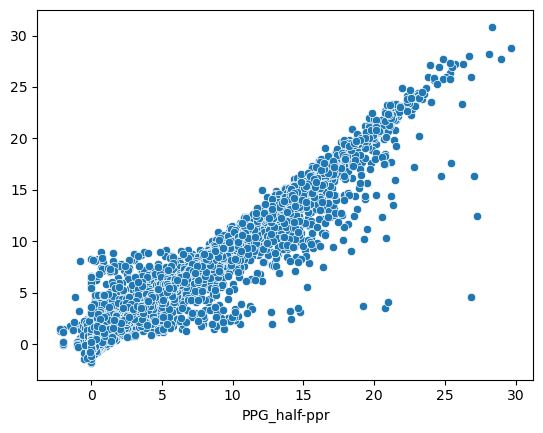

In [342]:
sns.scatterplot(x=y_train, y=linearreg.predict(X_train))

In [343]:
# Ahora aplicando el SVR o el Support Vector Regressor 

from sklearn.svm import SVR

# SVR pero le aplicamos un kernel tambien 
svr = Pipeline(steps=[
    ("pre", pre),                       
    ("model", SVR(kernel="rbf", C=10.0, epsilon=0.3, gamma="scale"))
])

svr.fit(X_train, y_train)

# Predicciones
yhat_tr = svr.predict(X_train)
yhat_te = svr.predict(X_test)

# r2
mae_tr = mean_absolute_error(y_train, yhat_tr)
r2_tr  = r2_score(y_train,  yhat_tr)
mae_te = mean_absolute_error(y_test,  yhat_te)
r2_te  = r2_score(y_test,   yhat_te)

print("SVR con un RBF")
print(f"Train  MAE: {mae_tr:.3f} | R²: {r2_tr:.3f}")
print(f"Test   MAE: {mae_te:.3f} | R²: {r2_te:.3f}")

SVR con un RBF
Train  MAE: 0.223 | R²: 0.989
Test   MAE: 0.284 | R²: 0.984


<Axes: xlabel='PPG_half-ppr'>

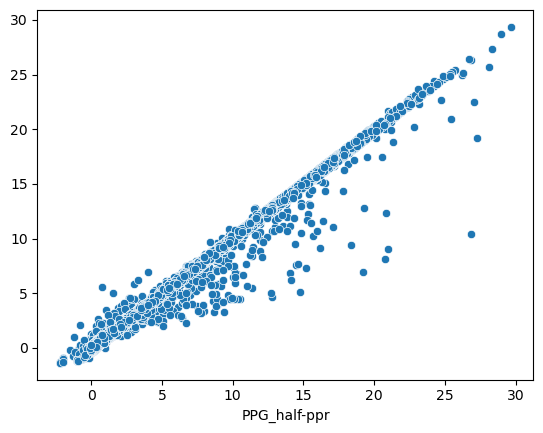

In [344]:
sns.scatterplot(x=y_train, y=svr.predict(X_train))

In [345]:
# Ahora vamos a intentar hablar de Random Forest
from sklearn.ensemble import RandomForestRegressor

randomforest = Pipeline(steps=[
    ("pre", pre),
    ("model", RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features="sqrt",   
        n_jobs=-1,
        random_state=42,
        oob_score=False
    ))
])

randomforest.fit(X_train, y_train)

yhat_tr = randomforest.predict(X_train)
yhat_te = randomforest.predict(X_test)

mae_tr = mean_absolute_error(y_train, yhat_tr)
r2_tr  = r2_score(y_train,  yhat_tr)
mae_te = mean_absolute_error(y_test,  yhat_te)
r2_te  = r2_score(y_test,   yhat_te)

print("RandomForest")
print(f"Train  MAE: {mae_tr:.3f} | R²: {r2_tr:.3f}")
print(f"Test   MAE: {mae_te:.3f} | R²: {r2_te:.3f}")

RandomForest
Train  MAE: 0.163 | R²: 0.996
Test   MAE: 0.439 | R²: 0.973


<Axes: xlabel='PPG_half-ppr'>

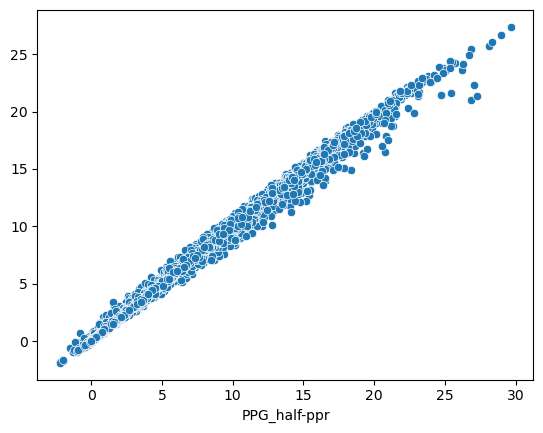

In [346]:
sns.scatterplot(x=y_train, y=randomforest.predict(X_train))

In [347]:
# Ahora haciendo un DecisionTree como ultimo modelo
from sklearn.tree import DecisionTreeRegressor

decisiontree = Pipeline(steps=[
    ("pre", pre),
    ("model", DecisionTreeRegressor(
        max_depth=8,         
        min_samples_leaf=20,  
        random_state=42
    ))
])

decisiontree.fit(X_train, y_train)

yhat_tr = decisiontree.predict(X_train)
yhat_te = decisiontree.predict(X_test)

mae_tr = mean_absolute_error(y_train, yhat_tr)
r2_tr  = r2_score(y_train,  yhat_tr)
mae_te = mean_absolute_error(y_test,  yhat_te)
r2_te  = r2_score(y_test,   yhat_te)

print("DecisionTreeRegressor")
print(f"Train  MAE: {mae_tr:.3f} | R²: {r2_tr:.3f}")
print(f"Test   MAE: {mae_te:.3f} | R²: {r2_te:.3f}")

DecisionTreeRegressor
Train  MAE: 0.662 | R²: 0.951
Test   MAE: 0.737 | R²: 0.938


<Axes: xlabel='PPG_half-ppr'>

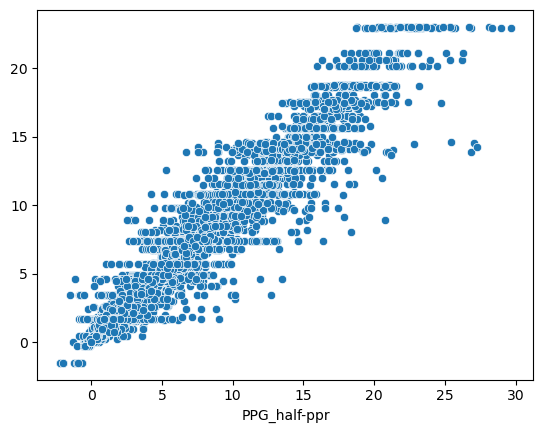

In [348]:
sns.scatterplot(x=y_train, y=decisiontree.predict(X_train))

In [349]:
# Por ultimo vamos a probar un XGBoost
from xgboost import XGBRegressor

xgb = Pipeline(steps=[
    ("pre", pre),
    ("model", XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb.fit(X_train, y_train)

yhat_tr = xgb.predict(X_train)
yhat_te = xgb.predict(X_test)

mae_tr = mean_absolute_error(y_train, yhat_tr)
r2_tr  = r2_score(y_train,  yhat_tr)
mae_te = mean_absolute_error(y_test,  yhat_te)
r2_te  = r2_score(y_test,   yhat_te)

print("XGBoost")
print(f"Train  MAE: {mae_tr:.3f} | R²: {r2_tr:.3f}")
print(f"Test   MAE: {mae_te:.3f} | R²: {r2_te:.3f}")


XGBoost
Train  MAE: 0.061 | R²: 1.000
Test   MAE: 0.192 | R²: 0.994


<Axes: xlabel='PPG_half-ppr'>

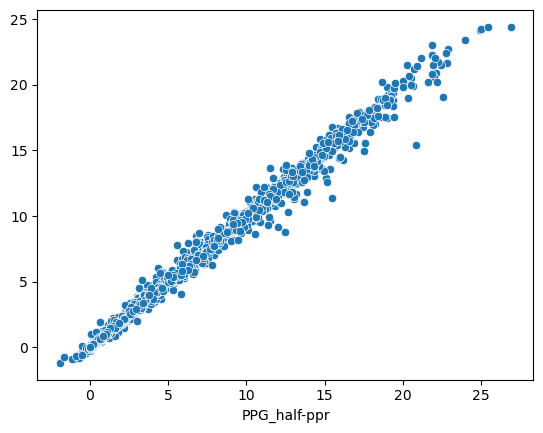

In [350]:
sns.scatterplot(x=y_test, y=xgb.predict(X_test))

La verdad es nuestros modelos nos dieron muy buenas métricas entonces decidimos que no era necesario el uso de hiperparametros.

Decidimos usar dos tipos de métricas la primera MAE la cual es la que nos ayuda ver cuantos puntos fantasy nos equivocamos en usando el dicho modelo dependiendo de cual fuese, el MAE nos indica cuanto se equivoca el modelo en puntos.
Y tambien decidimos usar el R2 para ver cuanto era que el modelo estaba reportando la variabilidad de nuestra aplicabilidad sobre el mismo, además de que el R2 nos ayuda a comparar con otros modelos para ver su eficiencia. 

Al final ya que comparamos todos los modelos nos dimos cuenta que el que mejor performance nos dio fue justamente el SVR con un kernel RBF, fue el que mejor relación R2 y MAE nos dio, de los 5 que probamos. 
SIN EMBARGO, a medio proceso de entrega y en nustras conclusiones, nos dimos cuenta de que SVR con RBF al ser de caja negra no tenemos intepretabilidad entonces realmente no podíamos saber cuales eran nustras variables más importantes entonces pues cambiamos al XGBoost, que de igual manera tiene los performance muy bien nada más que la relación de train y test no nos encantó tanto. 

La relación que tenemos en nuestro Train y Test del modelo de SVR que habíamos elegido originalmente es sana y consideramos que no está haciendo ni Overfitting ni Underfitting.

### Estas son los performance de SVR con un RBF:
- Train: MAE = 0.223, R² = 0.989

- Test: MAE = 0.284, R² = 0.984

Ahora viendo las de xgb

### Estas son los performance de XGBoost:
- Train:  MAE = 0.061, R² = 1.000

- Test:   MAE = 0.192, R² = 0.994

De todos modos pensamos que la diferencia no es tan exagerada, pero creemos que es algo a tomar en cuenta.

Ahora yendo con los sinteticos

In [351]:
# mejor mdoelo por la relación de train y test decidimos que es svr y ese usaremos pasa los sinteticos,
# pero para la interpretabilidad que necesitaremos más abajo usaremos el xgboost
N = 200
# separamos de nuevo las numericas y las categoricas
cat_cols = [c for c in X_train.columns if X_train[c].dtype.name in ("object","category")]
num_cols = [c for c in X_train.columns if c not in cat_cols]
# las numericas las ponemos con un rango real para usarlas
q = X_train[num_cols].quantile([0.05, 0.95])
low, high = q.loc[0.05], q.loc[0.95]

rng = np.random.default_rng(42)
num_new = pd.DataFrame({c: rng.uniform(low[c], high[c], size=N) for c in num_cols})

int_like = [c for c in num_cols
            if np.allclose(X_train[c].dropna(), np.round(X_train[c].dropna()))]
for c in int_like:
    num_new[c] = np.round(num_new[c]).astype(int)

cat_new = {}
for c in cat_cols:
    freqs = X_train[c].dropna().value_counts(normalize=True)
    cat_new[c] = rng.choice(freqs.index, size=N, p=freqs.values)
cat_new = pd.DataFrame(cat_new)

df_new = pd.concat([num_new, cat_new], axis=1)[X_train.columns]

y_pred_new = svr.predict(df_new)

df_pred = df_new.copy()
df_pred["PPG_half-ppr_pred"] = y_pred_new

# para ver los datos sinteticos
print(df_pred)
df_pred.to_csv("predicciones_sinteticas_reg.csv", index=False)


      Tm Pos  Age   G  GS  Pass_Cmp  Pass_Att  Pass_Yds  Pass_TD  Pass_Int  \
0    NWE  RB   31  13   5        78       203       114        6         3   
1    CLE  RB   27  16  15       125        87       839        6         0   
2    PIT  RB   31   9  13       148       245       236        8         7   
3    JAX  WR   30   3   2       118       163       279        7         2   
4    NOR  WR   23   1  16       158        35      1158        0         1   
..   ...  ..  ...  ..  ..       ...       ...       ...      ...       ...   
195  SEA  TE   24   8   4        57       120       352        2         5   
196  NYJ  TE   29  13  11         3       176       404        5         1   
197  JAX  WR   32   5  10        27         1      1202        9         1   
198  NWE  RB   24   8  16       119       273       529        6         6   
199  LAC  TE   25   8  10       116        77      1346        4         2   

     ...  Scrim_Yds  num_games  games_played_pct  games_started

# Ahora las conclusiones

Probamos cinco modelos tras eliminar las variables que podían reconstruir directamente el puntaje (todas las _per_game que forman la fórmula de half-PPR) y tras codificar Pos y Tm con one-hot. La métrica principal fue MAE (puntos fantasy/juego) y R².

SVR (RBF) fue nuestro mejor modelo.
Captura relaciones no lineales, con los hiperparámetros que usamos, entregó un MAE_test bajo y R²_test alto con una brecha train–test pequeña, lo que indica buena generalización y un buen performance.
De las ventajas podríamos decir que es flexible y tiene un buen compromiso sesgo-varianza.
De las desventajas sabemos que es menos interpretable, el entrenamiento podría ser más costoso en n grande y es sensible a la escala.

Random Forest.
Maneja bien las interacciones, no sigue linealidades y tambien nos da importancias de variables. El rendimiento fue cercano al SVR, aunque con tendencia a overfitting un poquito.
Ventajas: realmente no necesitamos un feature.
Desventajas: no es tan preciso cuando tenemos datos extremos.

Decision Tree.
Útil para ver las ramificaciones y lo que va haciendo, pero peor performance que SVR Y RF.
Ventajas: Es mucho más interpretable. 
Desventajas: nos da una buena varianza si tenemos muchos datos si tenemos pocos tiende a underfittear.

Linear y Lasso.
Funcionan bien cuando la relación es casi lineal y hay colinealidad residual. Después de retirar las variables que nos podían causardaño en colinealidad, su rendimiento fue correcto, aunque inferior a los modelos no lineales.
Ventajas: coeficientes interpretables y nos da control de colinealidad.
Desventajas: limitados si la relación real no es lineal. 

XGBoost.
Lo tomamos porque es uno de los modelos más populares que mejores resultados tienen y tambien por su interpretabilidad.
De Ventajas: incorpora regularización que ayuda, maneja tambien valores nulos y nos ofrece metricas claras de importancia de variables
De Desventajas: es más sensible a lo que hayamos hecho en hiperparámetros y puede llegar a ser sensible a outliers. 

Al final terminamos eligiendo XGBoost porque tiene muy buenos resultados y nos da esa buena interpretabilidad que estamos buscando para poder explicar relaciones y ver distintas cosas.








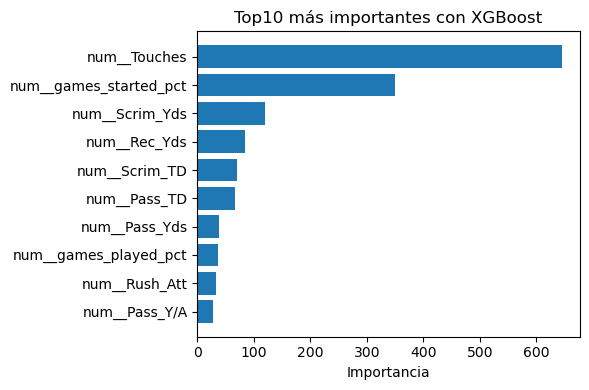

In [352]:
# construccion de grafico de las 10 variables más importantes

feat_names = xgb.named_steps["pre"].get_feature_names_out()

booster = xgb.named_steps["model"].get_booster()
gain_dict = booster.get_score(importance_type="gain") 

imp = np.zeros(len(feat_names))
for k, v in gain_dict.items():
    idx = int(k[1:])         
    if idx < len(imp):
        imp[idx] = v

idx = np.argsort(imp)[::-1][:10]
top_names = np.array(feat_names)[idx]
top_vals  = imp[idx]

plt.figure(figsize=(6,4))
plt.barh(range(10), top_vals[::-1])
plt.yticks(range(10), top_names[::-1])
plt.xlabel("Importancia")
plt.title("Top10 más importantes con XGBoost")
plt.tight_layout()
plt.show()

Y por ultimo para con el gráfico anterior podemos concluir que las variables más importantes son Touches y games started.

Esto que nos indica:

Esto nos indica que el volumen (osea la cantidad de veces un jugador está involucrado en el juego significativo que da puntos) es el rey en esto del fantasy, cuando un jugador es titular eso quiere decir que obviamente va a tener las jugadas o el tiempo de calidad para poder puntuar en el fantasy, y touches que es nuestra variable más fuerte obviamente refiere a la cantidad de veces que el jugador toca el balón, así como nuestra tercera más importante, los scrim yds que son los scrimmage yards, los cuales son una suma del total de recepcion, pase, y corriendo de yardas que haga un jugador en la vida real, estas dan un puntaje en el fantasy y por eso es la tercera mejor relacionada.